In [1]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
data = pd.read_csv('Salary_Data.csv')
data.head()

,YearsExperience,Age,Income
0,1.1,21.0,39343
1,1.3,21.5,46205
2,1.5,21.7,37731
3,2.0,22.0,43525
4,2.2,22.2,39891


Text(0, 0.5, 'Income')

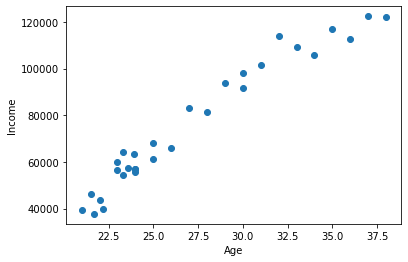

In [3]:
plt.scatter(data.Age,data['Income'])
plt.xlabel('Age')
plt.ylabel('Income')

In [4]:
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(data[['Age','Income']])
y_predicted

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2,
       2, 1, 1, 1, 1, 1, 1, 1])

In [5]:
data['cluster']=y_predicted
data.head()

,YearsExperience,Age,Income,cluster
0,1.1,21.0,39343,0
1,1.3,21.5,46205,0
2,1.5,21.7,37731,0
3,2.0,22.0,43525,0
4,2.2,22.2,39891,0


In [6]:
km.cluster_centers_

array([[2.33235294e+01, 5.45702353e+04],
       [3.50000000e+01, 1.14670286e+05],
       [2.91666667e+01, 9.16173333e+04]])

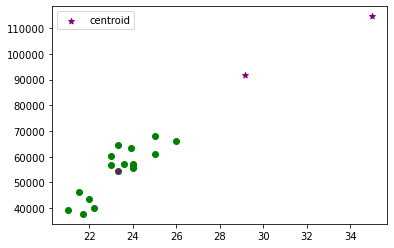

In [7]:
df1 = data[data.cluster==0]
plt.scatter(df1.Age,df1['Income'],color='green')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.legend()

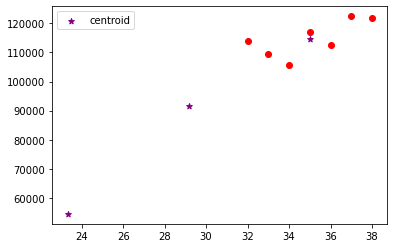

In [8]:
df2 = data[data.cluster==1]
plt.scatter(df2.Age,df2['Income'],color='red')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.legend()

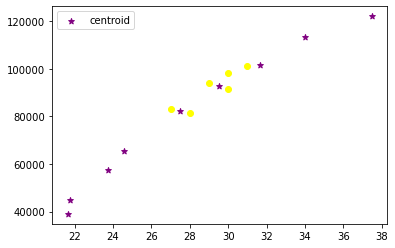

In [15]:
df3 = data[data.cluster==2]
plt.scatter(df3.Age,df3['Income'],color='yellow')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.legend()

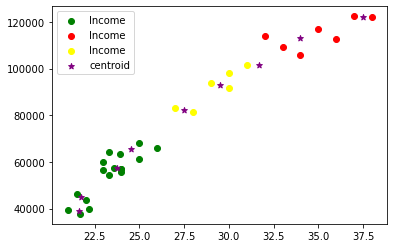

In [14]:
df1 = data[data.cluster==0]
plt.scatter(df1.Age,df1['Income'],color='green', label='Income')
df2 = data[data.cluster==1]
plt.scatter(df2.Age,df2['Income'],color='red', label='Income')
df3 = data[data.cluster==2]
plt.scatter(df3.Age,df3['Income'],color='yellow', label='Income')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color='purple',marker='*',label='centroid')
plt.legend()

In [12]:
sse = []
k_rng = range(1,10)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(data[['Age','Income']])
    sse.append(km.inertia_)

C:\Users\Nuwandhi\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


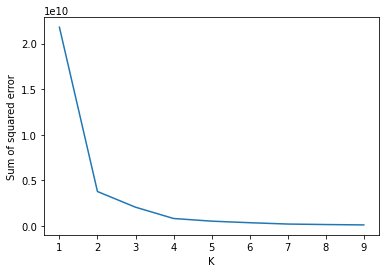

In [13]:
plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng,sse)